# Distributed SNP: Paper Analysis & Visualization

This notebook generates the visualizations for the Distributed SNP paper.
It covers:
1. Scaling Benchmarks (Execution Time vs Input Size)
2. Distribution Benchmarks (Stability across input types)
3. Profiling Breakdown (MPI vs Compute)
4. Memory Hierarchy Analysis (L1/L2/DRAM usage)
5. Partitioning Strategy Comparison

## Implementations
- `cpu`
- `optimized-cuda`
- `sparse-cuda`
- `naive-cuda-mpi` (linear, louvain, red-blue)
- `optimized-cuda-mpi` (linear, louvain, red-blue)

In [8]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---

# Timestamps (Update these based on your runs)
TS_SCALING = "20260107_152415" # Done
TS_DISTRIBUTION = "20260106_182837" # Pending
TS_NSYS = "20260105_160439" # Pending
TS_NCU = "20260106_190353" # Pending

# Base Paths
BENCHMARK_RESULTS_DIR = Path("benchmark/results")
PROFILING_RESULTS_DIR = Path("profiling/results")
NSYS_DIR = PROFILING_RESULTS_DIR / "nsys" / TS_NSYS
NCU_DIR = PROFILING_RESULTS_DIR / "ncu" / TS_NCU

# Plotting Style for Paper (Two Column)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 12,
    'font.family': 'serif' # Matching typical LaTeX font
})

# Color Palette
IMPL_COLORS = {
    'cpu': '#E74C3C',                   # Red
    'optimized-cuda': '#3498DB',        # Blue
    'sparse-cuda': '#9B59B6',           # Purple
    
    # Naive MPI (Greys/Silvers)
    'naive-cuda-mpi:linear': '#95A5A6',
    'naive-cuda-mpi:louvain': '#7F8C8D',
    'naive-cuda-mpi:red-blue': '#BDC3C7',
    
    # Optimized MPI (Greens/Teals)
    'optimized-cuda-mpi:linear': '#2ECC71',
    'optimized-cuda-mpi:louvain': '#27AE60',
    'optimized-cuda-mpi:red-blue': '#1ABC9C',
    
    # Generic mappings if exact match fails
    'naive-cuda-mpi': '#95A5A6',
    'optimized-cuda-mpi': '#27AE60'
}

print("✓ Configuration loaded.")

✓ Configuration loaded.


In [9]:
def load_benchmark_data(timestamp):
    """Parses Google Benchmark JSON output."""
    json_path = BENCHMARK_RESULTS_DIR / timestamp / "data.json"
    if not json_path.exists():
        print(f"⚠ Warning: Benchmark file not found: {json_path}")
        return pd.DataFrame()
    
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    records = []
    for bench in data['benchmarks']:
        name = bench['name']
        parts = name.split('/')
        # Format: Implementation/Distribution/Size/MaxVal/iterations...
        if len(parts) >= 3:
            impl = parts[0]
            dist = parts[1]
            try:
                size = int(parts[2])
            except ValueError:
                size = 0
            
            records.append({
                'Implementation': impl,
                'Distribution': dist,
                'Size': size,
                'RealTime': bench['real_time'], # Keep original unit (likely ns or ms)
                'TimeUnit': bench.get('time_unit', 'ns'),
                'RunType': bench.get('run_type', 'iteration')
            })
            
    df = pd.DataFrame(records)
    
    # Normalize Time to Milliseconds
    if not df.empty:
        # Google Benchmark often outputs in ns, but specifies 'ms' in time_unit
        # We'll normalize everything to MS
        def to_ms(row):
            t = row['RealTime']
            u = row['TimeUnit']
            if u == 'ns': return t / 1e6
            if u == 'us': return t / 1e3
            if u == 'ms': return t
            if u == 's': return t * 1e3
            return t
        
        df['TimeMS'] = df.apply(to_ms, axis=1)
        
    return df

def load_nsys_summary(impl_name, rank=0):
    """Loads aggregated Nsys stats for a specific implementation and rank."""
    base = NSYS_DIR / impl_name
    # Try getting statistics files
    # Need to handle different rank file naming patterns if necessary
    # Pattern: snp_profile_<host>_rank<rank>_stats_<type>.csv
    # We use glob to be safe
    
    # 1. GPU Kernel Time
    gpu_files = list(base.glob(f"*rank{rank}*stats_cuda_api_gpu_sum.csv"))
    if not gpu_files: 
        # Fallback for single rank without rank0 in name
        gpu_files = list(base.glob(f"*stats_cuda_api_gpu_sum.csv"))
        
    # 2. MPI Time
    mpi_files = list(base.glob(f"*rank{rank}*stats_mpi_event_sum.csv"))
    if not mpi_files:
        mpi_files = list(base.glob(f"*stats_mpi_event_sum.csv"))

    metrics = {'CUDA Kernel': 0, 'CUDA Memory': 0, 'MPI': 0, 'CPU': 0, 'Total': 0}
    
    if gpu_files:
        try:
            df_gpu = pd.read_csv(gpu_files[0])
            metrics['CUDA Kernel'] = df_gpu[df_gpu['Category'] == 'CUDA_KERNEL']['Total Time (ns)'].sum()
            metrics['CUDA Memory'] = df_gpu[df_gpu['Category'] == 'MEMORY_OPER']['Total Time (ns)'].sum()
        except Exception as e:
            print(f"  Error reading GPU file for {impl_name}: {e}")

    if mpi_files:
        try:
            df_mpi = pd.read_csv(mpi_files[0])
            metrics['MPI'] = df_mpi['Total Time (ns)'].sum()
        except Exception as e:
            pass # No MPI data is fine for non-MPI impls
            
    # For CPU/Total time, ideally we query the sqlite DB timeline.
    # As a simplification using CSVs only, we approximate Total = sum of parts + overhead?
    # Or better, we assume the benchmark runs reported Wall Time elsewhere, but here we want breakdown.
    # Let's approximate Total from the sum of components for the stacked bar
    # OR if we had total duration, CPU = Total - (GPU + MPI).
    # Since we lack the SQLite query capability in this simple extractor without complex logic,
    # let's assume valid CPU compute time is missing from these specific CSVs and focus on comparing
    # GPU vs MPI vs Memory costs, or try to infer.
    # The 'combined_analysis' script used SQLite for total time. 
    # Valid approximation: The sum of these parts is the "Device/Network Active Time".
    # We will display these components.
    
    return metrics

def load_ncu_metrics(impl_name):
    """Loads Ncu metrics CSV."""
    path = NCU_DIR / impl_name / "snp_profile_metrics.csv"
    if not path.exists(): return None
    
    try:
        # Skip unit row (index 1 in 0-based read, so row 2 in file)
        df = pd.read_csv(path, header=0)
        df = df.drop(0).reset_index(drop=True) # Drop unit row
        
        # Convert numeric
        cols_to_convert = [c for c in df.columns if 'sum' in c or 'avg' in c or 'pct' in c]
        for c in cols_to_convert:
            df[c] = pd.to_numeric(df[c], errors='coerce')
            
        return df
    except Exception:
        return None

print("✓ Data loaders defined.")

✓ Data loaders defined.


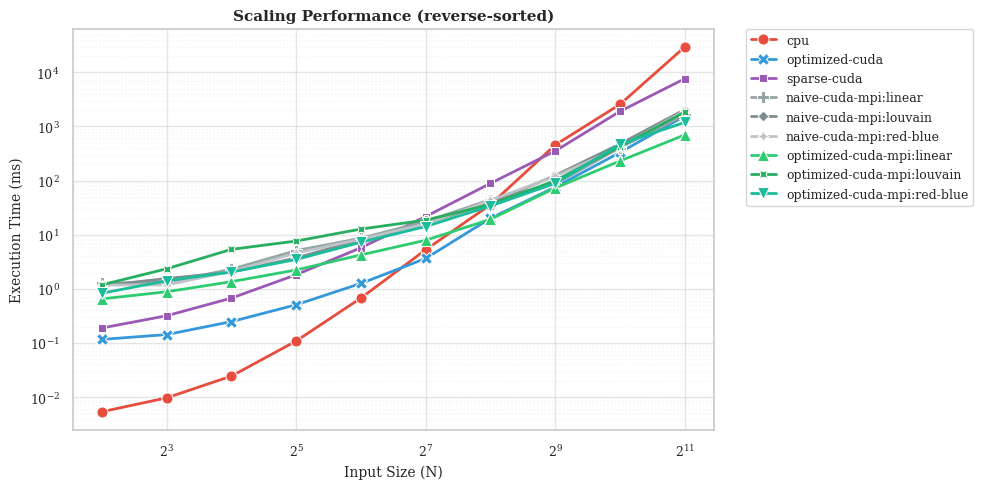

In [10]:
# --- 1. Scaling Benchmark Analysis ---

df_scale = load_benchmark_data(TS_SCALING)

if not df_scale.empty:
    # Filter for 'reverse-sorted' as it's the standard stress test
    # And run_type='iteration' to avoid aggregate stats
    target_dist = 'reverse-sorted'
    subset = df_scale[
        (df_scale['Distribution'] == target_dist) & 
        (df_scale['RunType'] == 'iteration')
    ].copy()
    
    if subset.empty:
        print(f"Warning: No data found for distribution '{target_dist}'. Using all available.")
        subset = df_scale.copy()
    
    plt.figure(figsize=(10, 5)) 
    
    sns.lineplot(
        data=subset,
        x='Size', y='TimeMS',
        hue='Implementation', style='Implementation',
        markers=True, dashes=False,
        palette=IMPL_COLORS,
        linewidth=2, markersize=8
    )
    
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.title(f'Scaling Performance ({target_dist})', fontweight='bold')
    plt.xlabel('Input Size (N)')
    plt.ylabel('Execution Time (ms)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.grid(True, which="major", ls="-", alpha=0.5)
    plt.grid(True, which="minor", ls=":", alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("No scaling data found.")

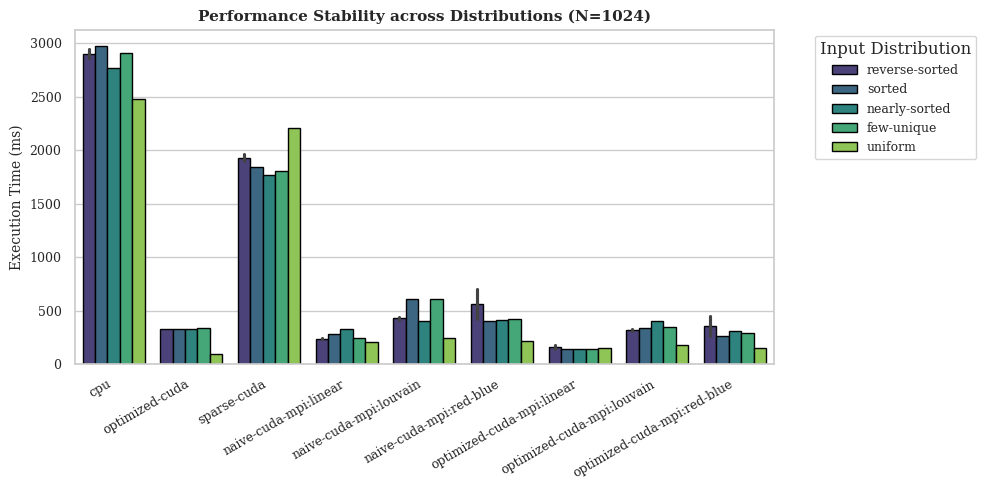

In [11]:
# --- 2. Distribution Stability Analysis ---

df_dist = load_benchmark_data(TS_DISTRIBUTION)

if not df_dist.empty:
    # Pick a common size to compare across distributions
    common_sizes = df_dist['Size'].mode()
    if not common_sizes.empty:
        target_size = common_sizes[0]
        subset_dist = df_dist[df_dist['Size'] == target_size].copy()
        
        plt.figure(figsize=(10, 5))
        
        sns.barplot(
            data=subset_dist,
            x='Implementation', y='TimeMS',
            hue='Distribution',
            palette='viridis',
            edgecolor='black'
        )
        
        plt.title(f'Performance Stability across Distributions (N={target_size})', fontweight='bold')
        plt.ylabel('Execution Time (ms)')
        plt.xlabel('')
        plt.xticks(rotation=30, ha='right')
        plt.legend(title='Input Distribution', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("Could not determine common size for distribution comparison.")
else:
    print("No distribution data found.")

<Figure size 1000x600 with 0 Axes>

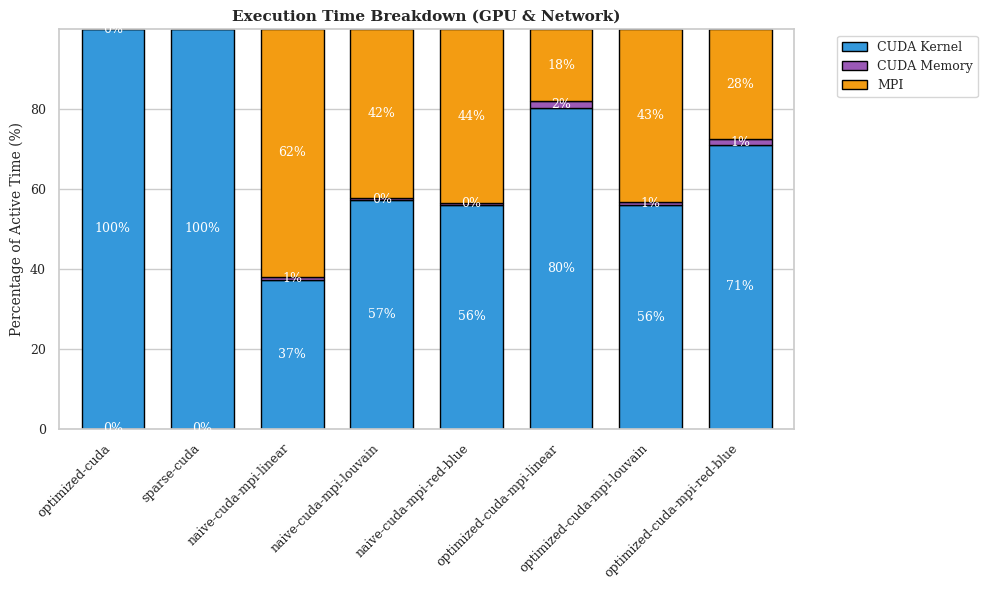

In [12]:
# --- 3. Profiling Breakdown (NSys) ---

# Implementations to check for profiling data
nsys_impls = [
    'optimized-cuda', 
    'sparse-cuda',
    'naive-cuda-mpi-linear', 
    'naive-cuda-mpi-louvain', 
    'naive-cuda-mpi-red-blue',
    'optimized-cuda-mpi-linear',
    'optimized-cuda-mpi-louvain',
    'optimized-cuda-mpi-red-blue'
]

breakdown_data = []

for impl in nsys_impls:
    # Check for rank 0 stats (usually the master rank)
    stats = load_nsys_summary(impl, rank=0)
    if stats['CUDA Kernel'] > 0 or stats['MPI'] > 0:
        breakdown_data.append({
            'Implementation': impl,
            'CUDA Kernel': stats['CUDA Kernel'],
            'CUDA Memory': stats['CUDA Memory'],
            'MPI': stats['MPI']
            # CPU time excluded as it requires timeline analysis not available in summary CSVs
        })

df_nsys = pd.DataFrame(breakdown_data)

if not df_nsys.empty:
    # Convert to Seconds
    for col in ['CUDA Kernel', 'CUDA Memory', 'MPI']:
        df_nsys[col] = df_nsys[col] / 1e9
        
    df_nsys.set_index('Implementation', inplace=True)
    
    # Calculate percentages for 100% stacked bar
    df_pct = df_nsys.div(df_nsys.sum(axis=1), axis=0) * 100
    
    plt.figure(figsize=(10, 6))
    
    # Plot Stacked Bar
    ax = df_pct.plot(
        kind='bar', stacked=True, 
        color=['#3498DB', '#9B59B6', '#F39C12'],
        edgecolor='black', width=0.7, figsize=(10, 6)
    )
    
    plt.title('Execution Time Breakdown (GPU & Network)', fontweight='bold')
    plt.ylabel('Percentage of Active Time (%)')
    plt.xlabel('')
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add labels
    for c in ax.containers:
        ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', fontsize=9)
        
    plt.tight_layout()
    plt.show()
else:
    print("No Nsys profiling data found.")

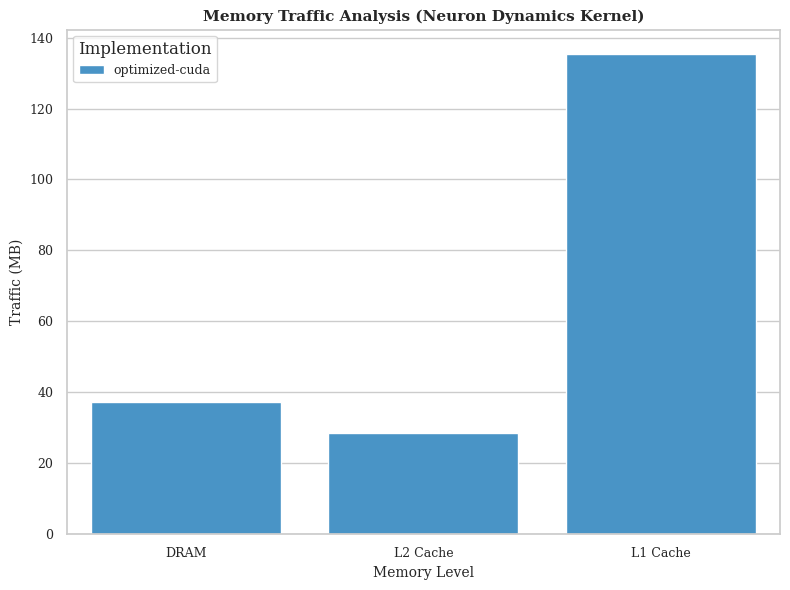

In [13]:
# --- 4. Memory Hierarchy Analysis (NCU) ---

ncu_impls = ['optimized-cuda', 'sparse-cuda']
ncu_frames = []

for impl in ncu_impls:
    df = load_ncu_metrics(impl)
    if df is not None:
        # Filter for main compute kernel usually "neuronDynamics" or similar
        # We'll take an average of all 'Dynamics' or 'Step' kernels
        # Identifying kernels by name
        df['Implementation'] = impl
        ncu_frames.append(df)

if ncu_frames:
    ncu_df = pd.concat(ncu_frames)
    
    # Identify relevant kernels (heuristic)
    # Looking for kernels with high duration or specific names
    ncu_df['KernelGroup'] = ncu_df['Kernel Name'].apply(
        lambda x: 'Neuron Dynamics' if 'neuronDynamics' in str(x) or 'Update' in str(x) else 'Other'
    )
    
    # Aggregating metrics
    # dram__bytes_read.sum + dram__bytes_write.sum = DRAM Traffic
    # lts__t_sectors_... = L2 Traffic (32 bytes/sector)
    # l1tex__t_bytes_... = L1 Traffic
    
    metrics = ncu_df.groupby(['Implementation', 'KernelGroup']).sum(numeric_only=True).reset_index()
    metrics = metrics[metrics['KernelGroup'] == 'Neuron Dynamics'] # Focus on main kernel
    
    if not metrics.empty:
        # Calculate in MB
        # Note: Units in CSV header were Mbyte for DRAM/L1, Sector for L2
        # We need to verify units. Based on typical NCU output:
        # If header said Mbyte, it's MB.
        # If lts is sectors, 1 sector = 32 bytes = 32e-6 MB
        
        # NOTE: This assumes the CSV loaded has columns named exactly this way.
        # Based on sample provided: 'dram__bytes_read.sum', 'lts__t_sectors_lookup_hit.sum', etc.
        
        plot_data = []
        for _, row in metrics.iterrows():
            dram = row.get('dram__bytes_read.sum', 0) + row.get('dram__bytes_write.sum', 0)
            l2_sectors = row.get('lts__t_sectors_lookup_hit.sum', 0) + row.get('lts__t_sectors_lookup_miss.sum', 0)
            l2 = l2_sectors * 32 / 1e6 # Sectors to MB
            l1 = (row.get('l1tex__t_bytes_lookup_hit.sum', 0) + row.get('l1tex__t_bytes_lookup_miss.sum', 0)) # Already MB?
            # Check L1 unit. If sample says Mbyte, then it is MB.
            # Sample: "l1tex... Mbyte". Yes.
            
            plot_data.append([row['Implementation'], 'DRAM', dram])
            plot_data.append([row['Implementation'], 'L2 Cache', l2])
            plot_data.append([row['Implementation'], 'L1 Cache', l1])
            
        df_mem = pd.DataFrame(plot_data, columns=['Implementation', 'Memory Level', 'Traffic (MB)'])
        
        plt.figure(figsize=(8, 6))
        sns.barplot(
            data=df_mem,
            x='Memory Level', y='Traffic (MB)',
            hue='Implementation', palette=IMPL_COLORS
        )
        plt.title('Memory Traffic Analysis (Neuron Dynamics Kernel)', fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("No matching kernels found for analysis.")
else:
    print("No NCU data found.")

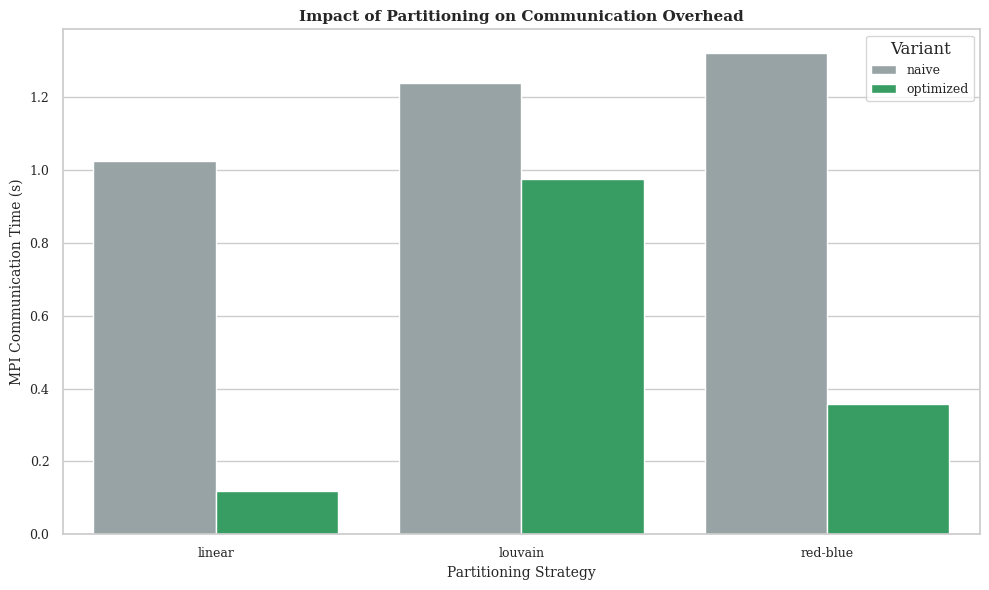

In [14]:
# --- 5. Partitioning Strategy Comparison ---

if 'df_nsys' in locals() and not df_nsys.empty:
    # Filter for MPI implementations
    mpi_df = df_nsys[df_nsys.index.str.contains('mpi')].copy()
    
    if not mpi_df.empty:
        # Extract Strategy and Variant
        def get_details(name):
            parts = name.split('-')
            # Ex: naive-cuda-mpi-linear -> Variant: naive, Strategy: linear
            # Ex: optimized-cuda-mpi-red-blue -> Variant: optimized, Strategy: red-blue
            variant = parts[0]
            strategy = '-'.join(parts[3:]) 
            return pd.Series([variant, strategy])
            
        mpi_df[['Variant', 'Strategy']] = mpi_df.index.to_series().apply(get_details)
        
        plt.figure(figsize=(10, 6))
        
        # Plot MPI Time Only
        sns.barplot(
            data=mpi_df.reset_index(),
            x='Strategy', y='MPI',
            hue='Variant',
            palette={'naive': '#95A5A6', 'optimized': '#27AE60'}
        )
        
        plt.title('Impact of Partitioning on Communication Overhead', fontweight='bold')
        plt.ylabel('MPI Communication Time (s)')
        plt.xlabel('Partitioning Strategy')
        plt.tight_layout()
        plt.show()
    else:
        print("No MPI data found for partitioning comparison.")
else:
    print("Nsys data unavailable. Cannot compare partitioning strategies.")